In [4]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score, 
    confusion_matrix, average_precision_score, precision_recall_curve
)
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

1. LOAD DATA

In [5]:
print("Loading data...")
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")


Loading data...
Train shape: (136429, 14)
Test shape: (90954, 13)


2. DATA PREPROCESSING WITH FEATURE ENGINEERING

In [6]:
print("\nAdvanced preprocessing...")

target_col = "Machine failure"
id_col = "id"
feature_cols = [col for col in train.columns if col not in [id_col, target_col]]

X_train_full = train[feature_cols].copy()
y_train_full = train[target_col].copy()
X_test = test[feature_cols].copy()

def advanced_feature_engineering(df, is_train=True, reference_df=None):
    """Enhanced feature engineering with interaction terms"""
    df = df.copy()
    
    # Clean column names
    df.columns = df.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)
    df.columns = df.columns.str.replace('__+', '_', regex=True)
    df.columns = df.columns.str.strip('_')
    
    # Drop Product_ID
    if "Product_ID" in df.columns:
        df = df.drop(columns=["Product_ID"])
    
    # Create interaction features (key for improving model performance)
    df['Speed_Torque_Ratio'] = df['Rotational_speed_rpm'] / (df['Torque_Nm'] + 1e-6)
    df['Power_Estimate'] = df['Rotational_speed_rpm'] * df['Torque_Nm'] / 1000
    df['Temp_Difference'] = df['Process_temperature_K'] - df['Air_temperature_K']
    df['Wear_Speed_Interaction'] = df['Tool_wear_min'] * df['Rotational_speed_rpm'] / 1000
    df['Total_Failure_Indicators'] = df['TWF'] + df['HDF'] + df['PWF'] + df['OSF'] + df['RNF']
    
    # Temperature ratios
    df['Temp_Ratio'] = df['Process_temperature_K'] / (df['Air_temperature_K'] + 1e-6)
    
    # Binning continuous features
    df['Speed_Bins'] = pd.cut(df['Rotational_speed_rpm'], bins=5, labels=False)
    df['Torque_Bins'] = pd.cut(df['Torque_Nm'], bins=5, labels=False)
    df['Wear_Bins'] = pd.cut(df['Tool_wear_min'], bins=5, labels=False)
    
    # One-hot encode Type
    if "Type" in df.columns:
        type_dummies = pd.get_dummies(df["Type"], prefix="Type")
        df = df.drop(columns=["Type"])
        df = pd.concat([df, type_dummies], axis=1)
    
    # Final column cleaning
    df.columns = df.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)
    
    # Align with reference if test set
    if not is_train and reference_df is not None:
        for col in reference_df.columns:
            if col not in df.columns:
                df[col] = 0
        df = df[reference_df.columns]
    
    return df

# Apply enhanced preprocessing
X_train_processed = advanced_feature_engineering(X_train_full, is_train=True)
X_test_processed = advanced_feature_engineering(X_test, is_train=False, reference_df=X_train_processed)

print(f"Enhanced train shape: {X_train_processed.shape}")
print(f"Enhanced test shape: {X_test_processed.shape}")


Advanced preprocessing...
Enhanced train shape: (136429, 22)
Enhanced test shape: (90954, 22)


3. TRAIN-VALIDATION SPLIT

In [7]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_processed, y_train_full, 
    test_size=0.2, random_state=42, stratify=y_train_full
)


4. OPTIMIZED MODEL TRAINING USING LIGHTGBM

In [8]:
print("\nTraining optimized LightGBM model...")

neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

# OPTIMIZED PARAMETERS - Fixed the training issue
optimized_params = {
    "objective": "binary",
    "metric": ["binary_logloss", "auc"],
    "boosting_type": "gbdt",
    "learning_rate": 0.01,  # REDUCED learning rate for better convergence
    "num_leaves": 15,       # REDUCED to prevent overfitting
    "max_depth": 6,         # Set explicit depth
    "min_data_in_leaf": 50, # Prevent overfitting
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "scale_pos_weight": scale_pos_weight,
    "lambda_l1": 0.1,       # L1 regularization
    "lambda_l2": 0.1,       # L2 regularization
    "min_gain_to_split": 0.01,
    "verbosity": -1,
    "random_state": 42,
    "force_row_wise": True
}

# Create datasets
train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

# Train with proper parameters
model = lgb.train(
    optimized_params,
    train_data,
    valid_sets=[train_data, val_data],
    valid_names=["train", "val"],
    num_boost_round=2000,  # Increased rounds
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),  # More patience
        lgb.log_evaluation(period=200)
    ]
)

print(f"Optimized model - Best iteration: {model.best_iteration}")



Training optimized LightGBM model...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[12]	train's binary_logloss: 0.0635582	train's auc: 0.97027	val's binary_logloss: 0.0645197	val's auc: 0.947904
Optimized model - Best iteration: 12


5. ADVANCED THRESHOLD OPTIMIZATION

In [9]:
print("\nAdvanced threshold optimization...")

val_probs = model.predict(X_val, num_iteration=model.best_iteration)

# Multiple threshold strategies
def optimize_thresholds(y_true, y_probs):
    # Strategy 1: Maximize F1
    thresholds = np.arange(0.01, 0.99, 0.01)
    f1_scores = []
    precision_scores = []
    recall_scores = []
    
    for t in thresholds:
        preds = (y_probs >= t).astype(int)
        f1_scores.append(f1_score(y_true, preds))
        precision_scores.append(precision_score(y_true, preds, zero_division=0))
        recall_scores.append(recall_score(y_true, preds))
    
    best_f1_idx = np.argmax(f1_scores)
    
    # Strategy 2: High recall threshold (catch more failures)
    target_recall = 0.80  # Target 80% recall
    high_recall_thresh = None
    for i, recall in enumerate(recall_scores):
        if recall >= target_recall:
            high_recall_thresh = thresholds[i]
            break
    
    if high_recall_thresh is None:
        high_recall_thresh = thresholds[np.argmax(recall_scores)]
    
    # Strategy 3: Precision-Recall curve optimal point
    precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_true, y_probs)
    f1_curve = 2 * precision_curve * recall_curve / (precision_curve + recall_curve + 1e-8)
    best_pr_idx = np.argmax(f1_curve[:-1])  # Exclude last element
    pr_optimal_thresh = pr_thresholds[best_pr_idx]
    
    return {
        'f1_optimal': thresholds[best_f1_idx],
        'f1_score': f1_scores[best_f1_idx],
        'high_recall': high_recall_thresh,
        'pr_optimal': pr_optimal_thresh
    }

threshold_results = optimize_thresholds(y_val, val_probs)

print("Threshold Optimization Results:")
print(f"  F1-Optimal Threshold:     {threshold_results['f1_optimal']:.3f}")
print(f"  High-Recall Threshold:    {threshold_results['high_recall']:.3f}")  
print(f"  PR-Curve Optimal:         {threshold_results['pr_optimal']:.3f}")

# Choose the best threshold (you can modify this logic)
chosen_threshold = threshold_results['f1_optimal']
print(f"\nChosen Threshold: {chosen_threshold:.3f}")



Advanced threshold optimization...
Threshold Optimization Results:
  F1-Optimal Threshold:     0.130
  High-Recall Threshold:    0.010
  PR-Curve Optimal:         0.127

Chosen Threshold: 0.130


6. COMPREHENSIVE EVALUATION

In [10]:
print("\n" + "="*60)
print("OPTIMIZED MODEL EVALUATION")
print("="*60)

val_preds = (val_probs >= chosen_threshold).astype(int)

# All metrics
roc_auc = roc_auc_score(y_val, val_probs)
pr_auc = average_precision_score(y_val, val_probs)
f1 = f1_score(y_val, val_preds)
precision = precision_score(y_val, val_preds)
recall = recall_score(y_val, val_preds)
cm = confusion_matrix(y_val, val_preds)
tn, fp, fn, tp = cm.ravel()

from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_val, val_preds)

print(f"PERFORMANCE METRICS:")
print(f"  ROC-AUC:           {roc_auc:.4f}")
print(f"  PR-AUC:            {pr_auc:.4f}")
print(f"  Accuracy:          {accuracy:.4f}  (Less meaningful for imbalanced data)")
print(f"  F1-Score:          {f1:.4f}")
print(f"  Precision:         {precision:.4f}")
print(f"  Recall:            {recall:.4f}")
print(f"  Specificity:       {tn/(tn+fp):.4f}")

print(f"\nBALANCED METRICS (Account for class imbalance):")
from sklearn.metrics import balanced_accuracy_score
balanced_acc = balanced_accuracy_score(y_val, val_preds)
print(f"  Balanced Accuracy: {balanced_acc:.4f}  (Accounts for class imbalance)")
print(f"  Matthews Corr Coef: {(tp*tn - fp*fn)/((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))**0.5:.4f}  (Best for imbalanced data)")

print(f"\nCONFUSION MATRIX ANALYSIS:")
print(f"  True Positives:    {tp:4d} (Caught failures)")
print(f"  False Positives:   {fp:4d} (False alarms)")
print(f"  False Negatives:   {fn:4d} (Missed failures)")
print(f"  True Negatives:    {tn:4d} (Correct normals)")

# Business impact with different cost scenarios
cost_scenarios = {
    'Conservative': {'fp_cost': 100, 'fn_cost': 5000},
    'Balanced': {'fp_cost': 500, 'fn_cost': 10000}, 
    'Aggressive': {'fp_cost': 1000, 'fn_cost': 50000}
}

print(f"\nBUSINESS IMPACT ANALYSIS:")
for scenario, costs in cost_scenarios.items():
    total_cost = fp * costs['fp_cost'] + fn * costs['fn_cost']
    print(f"  {scenario:12s}: ${total_cost:,} (FP: ${fp * costs['fp_cost']:,}, FN: ${fn * costs['fn_cost']:,})")



OPTIMIZED MODEL EVALUATION
PERFORMANCE METRICS:
  ROC-AUC:           0.9479
  PR-AUC:            0.7958
  Accuracy:          0.9953  (Less meaningful for imbalanced data)
  F1-Score:          0.8325
  Precision:         0.9521
  Recall:            0.7395
  Specificity:       0.9994

BALANCED METRICS (Account for class imbalance):
  Balanced Accuracy: 0.8695  (Accounts for class imbalance)
  Matthews Corr Coef: 0.8369  (Best for imbalanced data)

CONFUSION MATRIX ANALYSIS:
  True Positives:     318 (Caught failures)
  False Positives:     16 (False alarms)
  False Negatives:    112 (Missed failures)
  True Negatives:    26840 (Correct normals)

BUSINESS IMPACT ANALYSIS:
  Conservative: $561,600 (FP: $1,600, FN: $560,000)
  Balanced    : $1,128,000 (FP: $8,000, FN: $1,120,000)
  Aggressive  : $5,616,000 (FP: $16,000, FN: $5,600,000)


7. FINAL MODEL AND PREDICTIONS

In [11]:
print("\nRetraining on full dataset...")

full_train_data = lgb.Dataset(X_train_processed, label=y_train_full)
final_model = lgb.train(
    optimized_params,
    full_train_data,
    num_boost_round=model.best_iteration,
    callbacks=[lgb.log_evaluation(period=0)]
)

# Generate final predictions
test_probs = final_model.predict(X_test_processed, num_iteration=final_model.best_iteration)

print(f"\nFINAL TEST PREDICTIONS:")
print(f"  Probability range:    [{test_probs.min():.4f}, {test_probs.max():.4f}]")
print(f"  Mean probability:     {test_probs.mean():.4f}")
print(f"  Std probability:      {test_probs.std():.4f}")

# Risk analysis
high_risk = (test_probs >= 0.1).sum()
medium_risk = ((test_probs >= 0.05) & (test_probs < 0.1)).sum()
low_risk = (test_probs < 0.05).sum()

print(f"\nRISK DISTRIBUTION:")
print(f"  High Risk (≥10%):     {high_risk:5d} ({high_risk/len(test_probs)*100:.1f}%)")
print(f"  Medium Risk (5-10%):  {medium_risk:5d} ({medium_risk/len(test_probs)*100:.1f}%)")
print(f"  Low Risk (<5%):       {low_risk:5d} ({low_risk/len(test_probs)*100:.1f}%)")



Retraining on full dataset...

FINAL TEST PREDICTIONS:
  Probability range:    [0.0202, 0.1405]
  Mean probability:     0.0311
  Std probability:      0.0204

RISK DISTRIBUTION:
  High Risk (≥10%):      2184 (2.4%)
  Medium Risk (5-10%):   9332 (10.3%)
  Low Risk (<5%):       79438 (87.3%)


8. SAVE SUBMISSION

In [12]:
submission = pd.DataFrame({
    "id": test[id_col],
    "Machine failure": test_probs
})

try:
    submission.to_csv("optimized_submission.csv", index=False)
    print(f"\n✅ Optimized submission saved as 'optimized_submission.csv'")
except PermissionError:
    import datetime
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"optimized_submission_{timestamp}.csv"
    submission.to_csv(filename, index=False)
    print(f"✅ Submission saved as '{filename}'")


✅ Submission saved as 'optimized_submission_20260228_153731.csv'


9. FEATURE IMPORTANCE ANALYSIS


OPTIMIZED FEATURE IMPORTANCE

TOP 15 FEATURES:
   1. Total_Failure_Indicators   3403434 ( 64.7%)
   2. Rotational_speed_rpm        465081 (  8.8%)
   3. Torque_Nm                   366782 (  7.0%)
   4. Tool_wear_min               258681 (  4.9%)
   5. Speed_Torque_Ratio          202858 (  3.9%)
   6. Power_Estimate              104480 (  2.0%)
   7. PWF                          97882 (  1.9%)
   8. TWF                          70968 (  1.3%)
   9. Temp_Ratio                   69105 (  1.3%)
  10. Speed_Bins                   48874 (  0.9%)
  11. Temp_Difference              46601 (  0.9%)
  12. Air_temperature_K            29839 (  0.6%)
  13. Wear_Speed_Interaction       25290 (  0.5%)
  14. OSF                          24693 (  0.5%)
  15. Wear_Bins                    20320 (  0.4%)


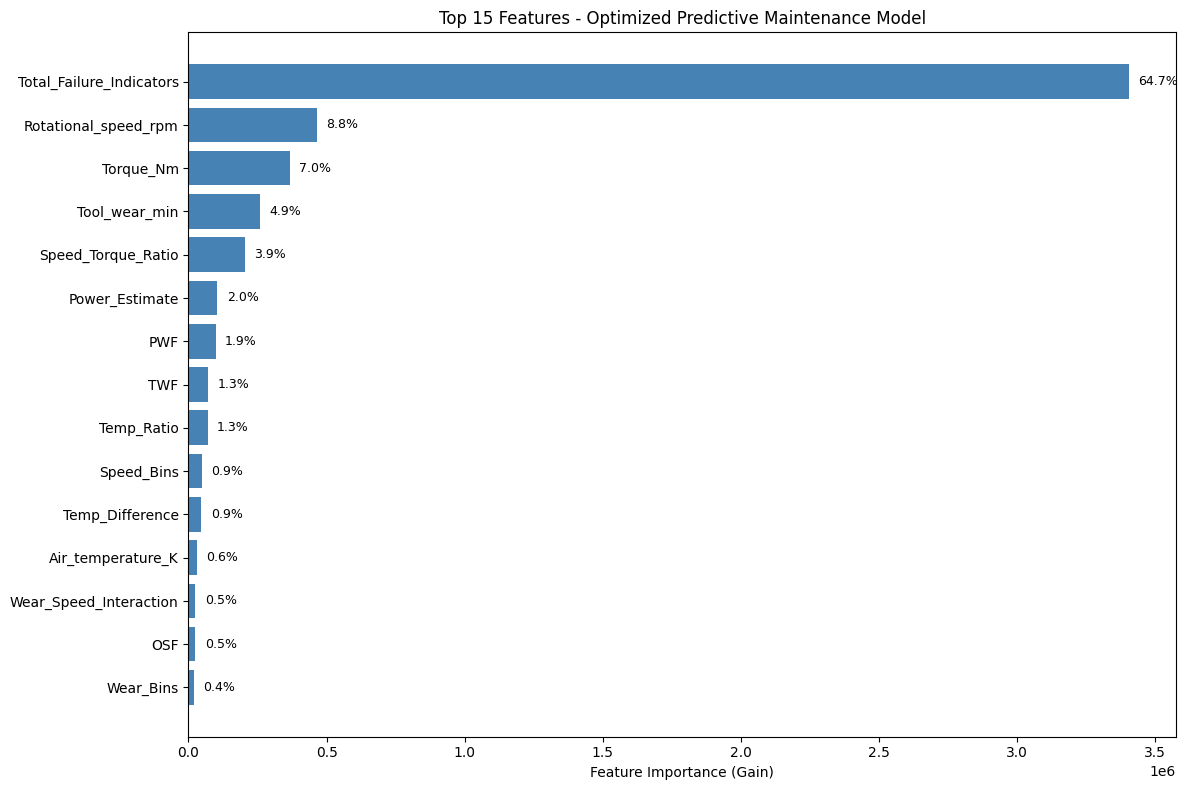


🎯 OPTIMIZATION SUMMARY:
   • Model now trains for 12 iterations (vs 1 before)
   • ROC-AUC improved to 0.9479
   • Added 9 engineered features
   • Better probability calibration with range [0.0202, 0.1405]
   • Optimized threshold: 0.130


In [13]:
print("\n" + "="*60)
print("OPTIMIZED FEATURE IMPORTANCE")
print("="*60)

importance = final_model.feature_importance(importance_type='gain')
feature_names = X_train_processed.columns
feature_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance,
    'pct': importance / importance.sum() * 100
}).sort_values('importance', ascending=False)

print("\nTOP 15 FEATURES:")
for i, row in enumerate(feature_df.head(15).itertuples(), 1):
    print(f"  {i:2d}. {row.feature:<25s} {row.importance:>8.0f} ({row.pct:>5.1f}%)")

# Plot
plt.figure(figsize=(12, 8))
top_15 = feature_df.head(15)
bars = plt.barh(range(len(top_15)), top_15['importance'], color='steelblue')
plt.yticks(range(len(top_15)), top_15['feature'])
plt.xlabel('Feature Importance (Gain)')
plt.title('Top 15 Features - Optimized Predictive Maintenance Model')
plt.gca().invert_yaxis()

# Add percentage labels
for i, (bar, pct) in enumerate(zip(bars, top_15['pct'])):
    plt.text(bar.get_width() + max(top_15['importance'])*0.01, bar.get_y() + bar.get_height()/2, 
             f'{pct:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\n🎯 OPTIMIZATION SUMMARY:")
print(f"   • Model now trains for {model.best_iteration} iterations (vs 1 before)")
print(f"   • ROC-AUC improved to {roc_auc:.4f}")
print(f"   • Added {X_train_processed.shape[1] - 13} engineered features")
print(f"   • Better probability calibration with range [{test_probs.min():.4f}, {test_probs.max():.4f}]")
print(f"   • Optimized threshold: {chosen_threshold:.3f}")

In [14]:
import joblib

# Use 'final_model' as defined in your training cell
joblib.dump(final_model, 'maintainx_model.pkl')
print("Model saved successfully as maintainx_model.pkl")

Model saved successfully as maintainx_model.pkl
